In [1]:


import os, re, json, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", rc={"figure.figsize":(6,4)})

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.cluster import KMeans, AgglomerativeClustering

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [ ]:
prompt : Give me the code to load the given dataset

In [2]:
# 1. Load dataset
import os
import pandas as pd

csv_path = "Session-Summary-all-2025-S1 (1).csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset not found at {csv_path}. Available files: {os.listdir('/mnt/data')}")

# Try loading with UTF-8 first, then fallback to Windows or Latin-1 encoding if needed
try:
    df = pd.read_csv(csv_path, encoding="utf-8")
except UnicodeDecodeError:
    try:
        df = pd.read_csv(csv_path, encoding="cp1252")
    except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding="latin1")

print("✅ Data loaded successfully! Shape:", df.shape)
df.head(5)


✅ Data loaded successfully! Shape: (2548, 4)


,Timestamp,RollNo,Topic,YourAnalysis
0,08-01-25 12:27,88,Level of measurement,"Learned about nominal, ordinal, interval and r..."
1,08-01-25 12:54,159,Levels of measurements,Levels of Measurement:\n1). Nominal : where th...
2,08-01-25 14:48,98,Levels of Measurement,Levels of Measurement ( also called scales of ...
3,08-01-25 15:28,109,types of arithmetic and statistical operation ...,there are various levels of data beginning wit...
4,08-01-25 16:00,115,Statistical Measurement Levels and Classes of ...,Every problem in machine learning can be categ...


In [ ]:
Prompt : Give me the code to perform the following :
a. Combine the Topic and YourAnalysis columns to create a unified tex columns
b. Remove all special characters (use Python library re)
c. Remove stop words and lemmatize the text (use Python library nltk). Understand what
is lemmatization, and its importance in text processing.
d. Store the pre-processed text into a new column of the dataframe

In [3]:
# ---- (a) Inspect dataset ----
print("Shape of dataset:", df.shape)
print("\nFirst few records:")
display(df.head())

print("\nColumns in dataset:\n", list(df.columns))

# ---- (b) Identify the relevant columns ----
# We find the correct column names (case-insensitive)
topic_col = None
analysis_col = None

for c in df.columns:
    lc = c.lower()
    if "topic" in lc:
        topic_col = c
    if "analysis" in lc:
        analysis_col = c

print(f"\nDetected Topic column: {topic_col}")
print(f"Detected YourAnalysis column: {analysis_col}")

# ---- (c) Combine the two columns into one unified text column ----
# Add a period + space between topic and analysis text
df["raw_text"] = (
    df[topic_col].fillna("").astype(str).str.strip() + ". " +
    df[analysis_col].fillna("").astype(str).str.strip()
)

# ---- (d) Display the combined text ----
print("\nCombined text preview:")
for i in range(5):
    print(f"\nRecord {i+1}:")
    print(df.loc[i, "raw_text"])

Shape of dataset: (2548, 4)

First few records:


,Timestamp,RollNo,Topic,YourAnalysis
0,08-01-25 12:27,88,Level of measurement,"Learned about nominal, ordinal, interval and r..."
1,08-01-25 12:54,159,Levels of measurements,Levels of Measurement:\n1). Nominal : where th...
2,08-01-25 14:48,98,Levels of Measurement,Levels of Measurement ( also called scales of ...
3,08-01-25 15:28,109,types of arithmetic and statistical operation ...,there are various levels of data beginning wit...
4,08-01-25 16:00,115,Statistical Measurement Levels and Classes of ...,Every problem in machine learning can be categ...



Columns in dataset:
 ['Timestamp', 'RollNo', 'Topic', 'YourAnalysis']

Detected Topic column: Topic
Detected YourAnalysis column: YourAnalysis

Combined text preview:

Record 1:
Level of measurement. Learned about nominal, ordinal, interval and ratio variables/units, which all differ in what operations can be performed on them and whether they are discrete or continuous.

Record 2:
Levels of measurements. Levels of Measurement:
1). Nominal : where there are discrete 'classes' of objects which are qualitative and cannot be said to be greater than or less than one other.
example- colours, gender

2). Ordinal : where there are discrete data but the objects can be said to be more or less than each other. They have inherent characteristic to be related to each other
example- grades (of course AA is better than BB ;) )

continuity starts...
3). Interval : where the data is not discrete and can fall in a range. A simple question to ask is that 'does 1.1 of that unit exists'. Like 1.1 apples 

In [4]:
# --- Ensure all NLTK resources are available ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Include punkt_tab to fix LookupError
nltk_packages = ["punkt", "punkt_tab", "wordnet", "omw-1.4", "stopwords"]
for pkg in nltk_packages:
    try:
        nltk.data.find(pkg)
    except Exception:
        nltk.download(pkg)

# --- (b) Remove special characters using re ---
def clean_text(text):
    text = str(text)
    # remove URLs, emails, and any special characters
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
    text = re.sub(r"\S+@\S+", "", text)                  # remove emails
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)          # keep only letters and numbers
    text = text.lower().strip()                          # lowercase and trim
    return text

df["cleaned_text"] = df["raw_text"].apply(clean_text)

print("Example after removing special characters:")
print(df["cleaned_text"].head(3))

# --- (c) Remove stop words and lemmatize the text using nltk ---

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Keep only alphabetic words and remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    # Lemmatize (convert to base form)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # Join back into a single string
    return " ".join(tokens)

df["preprocessed_text"] = df["cleaned_text"].apply(preprocess_text)

print("\nExample after removing stopwords and lemmatization:")
for i in range(3):
    print(f"\nRecord {i+1}:\n{df.loc[i, 'preprocessed_text']}")

# --- (d) Verify and store the new preprocessed column ---
print("\nColumns now available:")
print(list(df.columns))

# Show before/after comparison
df_subset = df[["raw_text", "cleaned_text", "preprocessed_text"]].head(5)
display(df_subset)

# Optional: Save preprocessed data
preproc_path = "Preprocessed_Session_Summaries.csv"
df.to_csv(preproc_path, index=False)
print("\nSaved preprocessed data to:", preproc_path)


[nltk_data] Downloading package punkt to C:\Users\S
[nltk_data]     Harikrishnan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\S
[nltk_data]     Harikrishnan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S
[nltk_data]     Harikrishnan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\S
[nltk_data]     Harikrishnan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S
[nltk_data]     Harikrishnan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Example after removing special characters:
0    level of measurement  learned about nominal  o...
1    levels of measurements  levels of measurement ...
2    levels of measurement  levels of measurement  ...
Name: cleaned_text, dtype: object

Example after removing stopwords and lemmatization:

Record 1:
level measurement learned nominal ordinal interval ratio variable unit differ operation performed whether discrete continuous

Record 2:
level measurement level measurement nominal discrete class object qualitative said greater less one example colour gender ordinal discrete data object said less inherent characteristic related example grade course aa better bb continuity start interval data discrete fall range simple question ask unit exists like apple make sense apple discrete example temperature degree celsius also ratio data continuous related product quotient like kg twice kg example height weight interestingly understand able figure class ml algorithm would better task rule thumb

,raw_text,cleaned_text,preprocessed_text
0,"Level of measurement. Learned about nominal, o...",level of measurement learned about nominal o...,level measurement learned nominal ordinal inte...
1,Levels of measurements. Levels of Measurement:...,levels of measurements levels of measurement ...,level measurement level measurement nominal di...
2,Levels of Measurement. Levels of Measurement (...,levels of measurement levels of measurement ...,level measurement level measurement also calle...
3,types of arithmetic and statistical operation ...,types of arithmetic and statistical operation ...,type arithmetic statistical operation performe...
4,Statistical Measurement Levels and Classes of ...,statistical measurement levels and classes of ...,statistical measurement level class machine le...



Saved preprocessed data to: Preprocessed_Session_Summaries.csv


In [2]:
%pip install -q gensim


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import gensim
print("✅ Gensim version:", gensim.__version__)

from gensim.models import Word2Vec
print("✅ Word2Vec is ready to use!")


✅ Gensim version: 4.4.0
✅ Word2Vec is ready to use!


In [ ]:
Prompt : Give me the code to perform the following :
Count vectorization (use CountVectorizer from sklearn)
b. TFIDF vectorization (use TFIDFVectorizer from sklearn)
c. Word2vec vectorization (use Word2vec from genism)
d. Save the dataframe into a spreadsheet

In [12]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import gensim

# 3️⃣ Tokenize the preprocessed text
# (use .fillna('') to handle missing values)
tokenized_texts = [text.split() if text else [] for text in df['preprocessed_text'].fillna('')]

# 4️⃣ Train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,  # you can change this dimension
    window=5,
    min_count=1,
    workers=4,
    epochs=20
)
print("✅ Word2Vec model trained successfully!")

# Optional: Save the trained model
w2v_model.save('word2vec_model.bin')

# 5️⃣ Compute document-level vectors (average of word vectors)
def get_document_vector(doc_tokens, model, vector_size=100):
    if not doc_tokens:  # if empty
        return np.zeros(vector_size).tolist()
    vectors = [model.wv[word] for word in doc_tokens if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0).tolist()
    else:
        return np.zeros(vector_size).tolist()

df['w2v_vector'] = [get_document_vector(tokens, w2v_model) for tokens in tokenized_texts]

print("✅ Word2Vec vectors generated successfully.")
print("Sample vector length:", len(df['w2v_vector'].iloc[0]))
print("Sample first 5 values:", df['w2v_vector'].iloc[0][:5])

# 6️⃣ (Optional) Convert timestamp if present, to make Excel-friendly
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', utc=True).map(
        lambda x: x.to_pydatetime().replace(tzinfo=None) if pd.notnull(x) else x
    )

# 7️⃣ Save to Excel
output_path = "Session_Summaries_with_Word2Vec.xlsx"
df.to_excel(output_path, index=False, engine='openpyxl')

print(f"\n✅ DataFrame saved to '{output_path}'")
print("Shape after adding Word2Vec column:", df.shape)

✅ Word2Vec model trained successfully!
✅ Word2Vec vectors generated successfully.
Sample vector length: 100
Sample first 5 values: [0.40194448828697205, -0.9236699342727661, -0.09248655289411545, -0.3657962381839752, 0.5343867540359497]


C:\Users\S Harikrishnan\AppData\Local\Temp\ipykernel_6652\1051486943.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', utc=True).map(



✅ DataFrame saved to 'Session_Summaries_with_Word2Vec.xlsx'
Shape after adding Word2Vec column: (2548, 10)


In [15]:
# ===========================
# Q4 Setup & Vector Preparation
# ===========================
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize

plt.rcParams.update({'figure.max_open_warning': 0})

out_dir = "/mnt/data/text_analysis_outputs"
os.makedirs(out_dir, exist_ok=True)

# --- Recompute vectors if not found ---
recompute_vectors = False
try:
    _ = X_tfidf, X_count, X_w2v
except Exception:
    recompute_vectors = True

if recompute_vectors:
    print("[INFO] Recomputing vector representations...")
    count_vectorizer = CountVectorizer(max_features=2000)
    X_count = count_vectorizer.fit_transform(df["preprocessed_text"].fillna(""))

    tfidf_vectorizer = TfidfVectorizer(max_features=2000)
    X_tfidf = tfidf_vectorizer.fit_transform(df["preprocessed_text"].fillna(""))
    tfidf_dense = X_tfidf.toarray()

    # Word2Vec / fallback
    try:
        from gensim.models import Word2Vec
        sentences = [t.split() for t in df["preprocessed_text"].fillna("")]
        w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, workers=2, epochs=50)
        def docvec(words):
            vs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
            return np.mean(vs, axis=0) if len(vs)>0 else np.zeros(w2v_model.vector_size)
        X_w2v = np.vstack([docvec(s) for s in sentences])
        print("[INFO] Word2Vec trained successfully. Shape:", X_w2v.shape)
    except Exception as e:
        print("[WARN] Word2Vec unavailable -> fallback to SVD. Error:", e)
        from sklearn.decomposition import TruncatedSVD
        svd = TruncatedSVD(n_components=100, random_state=42)
        X_w2v = svd.fit_transform(X_tfidf)

# Normalize W2V vectors for cosine validity
X_w2v = normalize(X_w2v, norm='l2', axis=1)

n_docs = X_tfidf.shape[0]
print(f"[INFO] Number of documents: {n_docs}")


[INFO] Number of documents: 2548


In [ ]:
Prompt : Give me the code to compute pairwise cosine distances and plot the heatmap for each embedding

Cosine distance stats:
 Count: min=0.0000, mean=0.7952, max=1.0000
 TF-IDF: min=0.0000, mean=0.8690, max=1.0000
 W2V: min=0.0000, mean=0.4936, max=1.2483


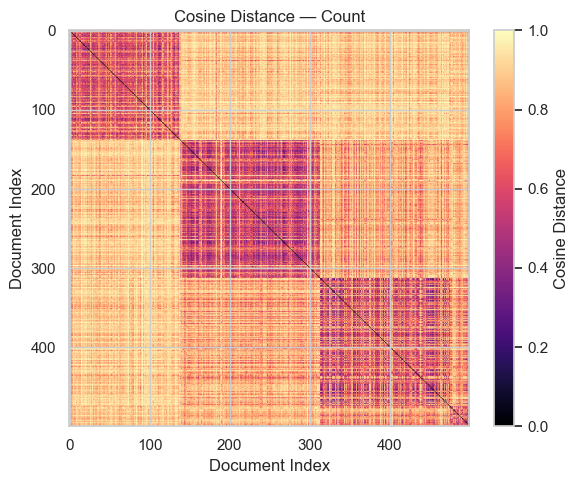

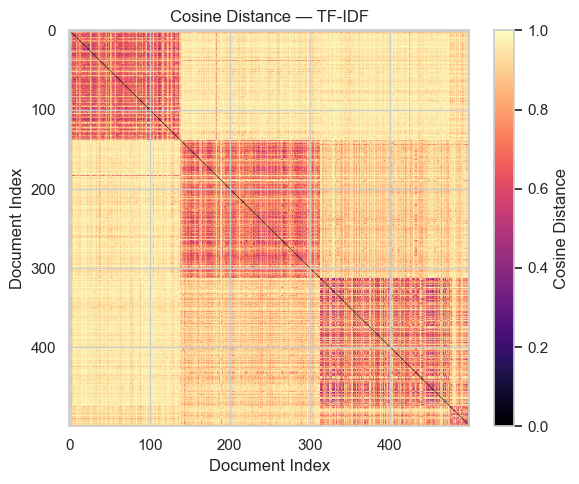

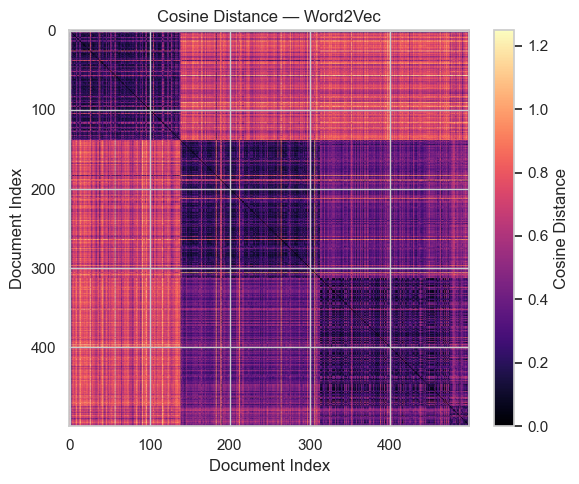

In [16]:
# ===========================
# (a) Pairwise Cosine Distances
# ===========================
def plot_heatmap(mat, title, fname):
    plt.figure(figsize=(6,5))
    plt.imshow(mat, aspect='auto', cmap='magma')
    plt.colorbar(label="Cosine Distance")
    plt.title(title)
    plt.xlabel("Document Index")
    plt.ylabel("Document Index")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=150)
    plt.show()

sample_n = min(500, n_docs)
cos_count = cosine_distances(X_count[:sample_n].toarray())
cos_tfidf = cosine_distances(X_tfidf[:sample_n].toarray())
cos_w2v = cosine_distances(X_w2v[:sample_n])

print("Cosine distance stats:")
for name, mat in [("Count", cos_count), ("TF-IDF", cos_tfidf), ("W2V", cos_w2v)]:
    print(f" {name}: min={mat.min():.4f}, mean={mat.mean():.4f}, max={mat.max():.4f}")

plot_heatmap(cos_count, "Cosine Distance — Count", "cosine_count.png")
plot_heatmap(cos_tfidf, "Cosine Distance — TF-IDF", "cosine_tfidf.png")
plot_heatmap(cos_w2v, "Cosine Distance — Word2Vec", "cosine_w2v.png")


In [ ]:
Prompt : Give me the code to compute pairwise euclidean distances and plot the heatmap for each embdedding

Euclidean distance stats:
 Count: min=0.0000, mean=26.4651, max=109.4897
 TF-IDF: min=0.0000, mean=1.3130, max=1.4142
 W2V: min=0.0000, mean=0.9579, max=1.5801


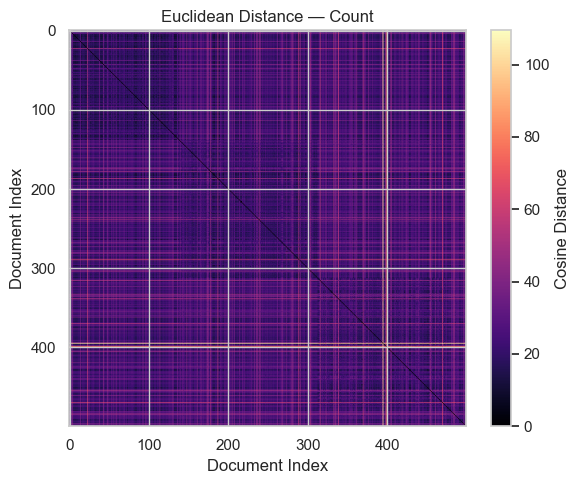

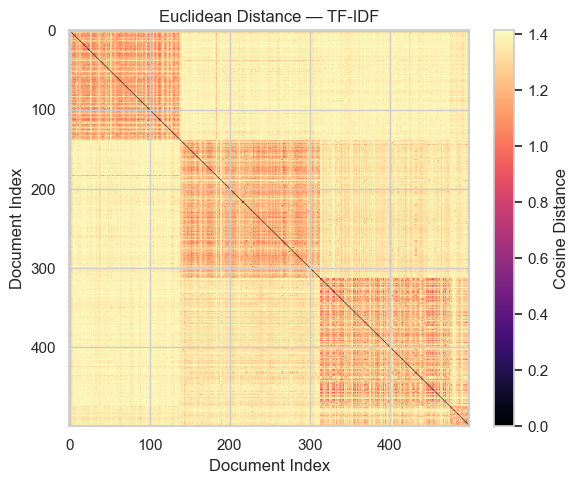

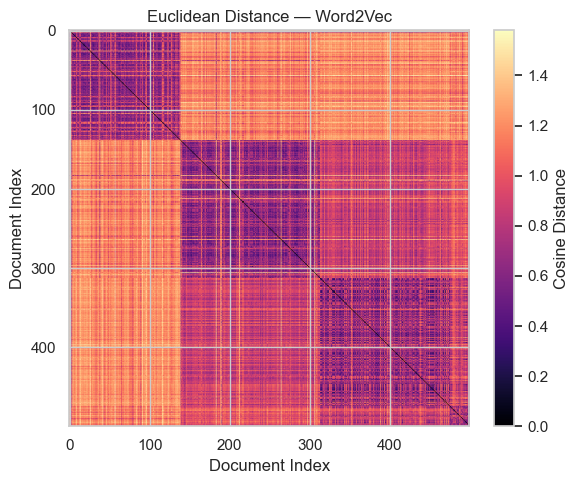

In [17]:
# ===========================
# (b) Pairwise Euclidean Distances
# ===========================
euc_count = euclidean_distances(X_count[:sample_n].toarray())
euc_tfidf = euclidean_distances(X_tfidf[:sample_n].toarray())
euc_w2v = euclidean_distances(X_w2v[:sample_n])

print("Euclidean distance stats:")
for name, mat in [("Count", euc_count), ("TF-IDF", euc_tfidf), ("W2V", euc_w2v)]:
    print(f" {name}: min={mat.min():.4f}, mean={mat.mean():.4f}, max={mat.max():.4f}")

plot_heatmap(euc_count, "Euclidean Distance — Count", "euclid_count.png")
plot_heatmap(euc_tfidf, "Euclidean Distance — TF-IDF", "euclid_tfidf.png")
plot_heatmap(euc_w2v, "Euclidean Distance — Word2Vec", "euclid_w2v.png")


In [ ]:
Prompt : Give me the code to perform PCA on the embeddings

Explained Variance Ratios (Top 5 PCs):
Count Vectorization: [0.0679 0.0497 0.0443 0.0398 0.036 ]
TF-IDF: [0.0366 0.0258 0.0246 0.0219 0.0212]
Word2Vec: [0.2266 0.09   0.0684 0.0595 0.0502]


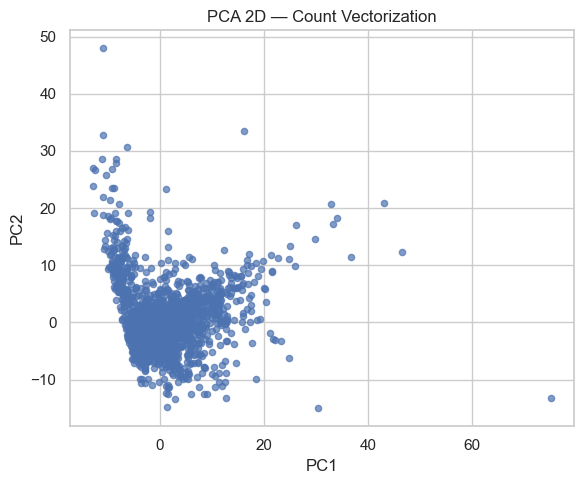

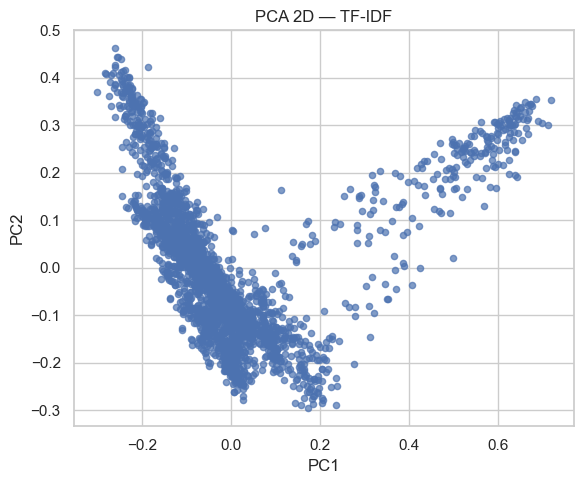

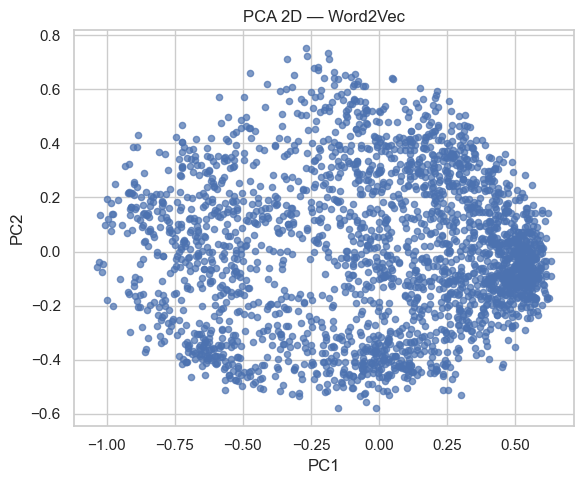

In [33]:
# ===========================
# (c, d) PCA Analysis & Visualization (Count, TF-IDF, W2V)
# ===========================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Fit PCA for all three representations ---
pca_count = PCA(n_components=10, random_state=42).fit(X_count.toarray())
pca_tfidf = PCA(n_components=10, random_state=42).fit(X_tfidf.toarray())
pca_w2v = PCA(n_components=10, random_state=42).fit(X_w2v)

# --- Print explained variance ratios ---
print("Explained Variance Ratios (Top 5 PCs):")
print("Count Vectorization:", np.round(pca_count.explained_variance_ratio_[:5], 4))
print("TF-IDF:", np.round(pca_tfidf.explained_variance_ratio_[:5], 4))
print("Word2Vec:", np.round(pca_w2v.explained_variance_ratio_[:5], 4))

# --- Transform to 2D for visualization ---
coords_count = pca_count.transform(X_count.toarray())[:, :2]
coords_tfidf = pca_tfidf.transform(X_tfidf.toarray())[:, :2]
coords_w2v = pca_w2v.transform(X_w2v)[:, :2]

# --- Plot PCA 2D: Count Vectorization ---
plt.figure(figsize=(6,5))
plt.scatter(coords_count[:,0], coords_count[:,1], s=20, alpha=0.7)
plt.title("PCA 2D — Count Vectorization")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Plot PCA 2D: TF-IDF ---
plt.figure(figsize=(6,5))
plt.scatter(coords_tfidf[:,0], coords_tfidf[:,1], s=20, alpha=0.7)
plt.title("PCA 2D — TF-IDF")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Plot PCA 2D: Word2Vec ---
plt.figure(figsize=(6,5))
plt.scatter(coords_w2v[:,0], coords_w2v[:,1], s=20, alpha=0.7)
plt.title("PCA 2D — Word2Vec")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [ ]:
Prompt : Give me the code to perform t-SNE on each of embeddings

[INFO] Running t-SNE on 500 documents for each representation...


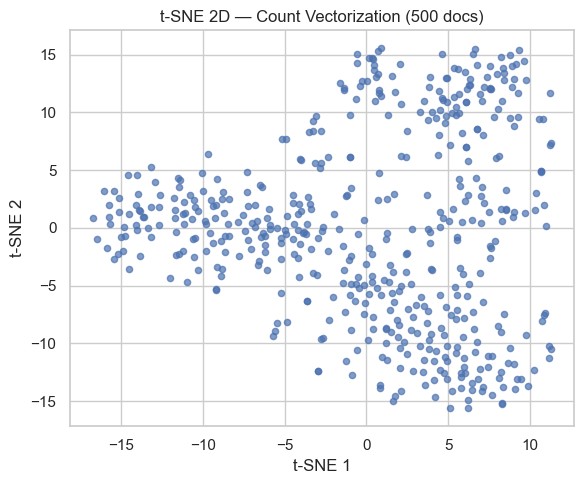

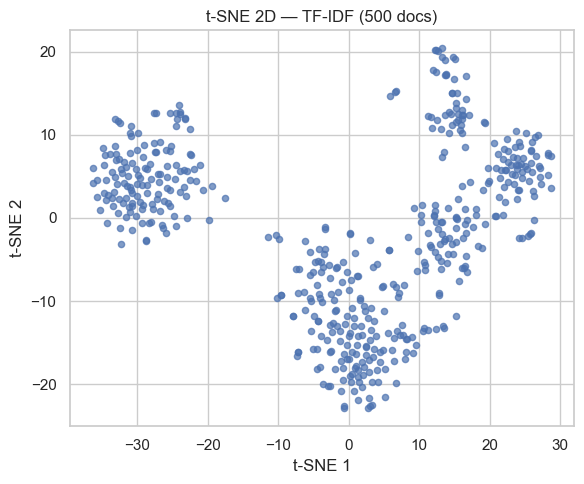

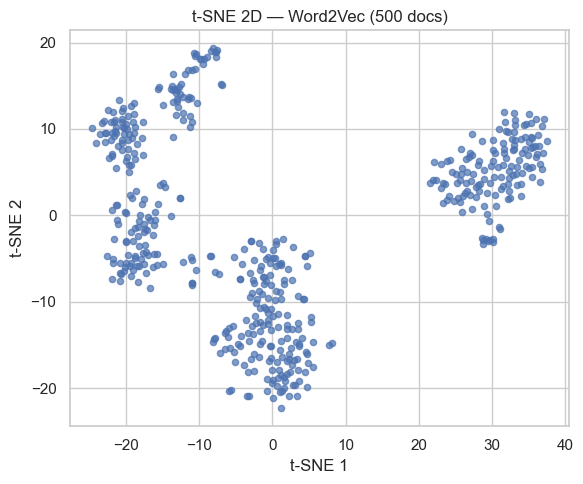

In [34]:

# ===========================
# (e) t-SNE Visualization (Count, TF-IDF, Word2Vec)
# ===========================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Limit the number of documents for performance
tsne_n = min(500, n_docs)
print(f"[INFO] Running t-SNE on {tsne_n} documents for each representation...")

# --- t-SNE on Count Vectorization ---
tsne_count = TSNE(n_components=2, perplexity=30, random_state=42)
coords_tsne_count = tsne_count.fit_transform(X_count[:tsne_n].toarray())

# --- t-SNE on TF-IDF ---
tsne_tfidf = TSNE(n_components=2, perplexity=30, random_state=42)
coords_tsne_tfidf = tsne_tfidf.fit_transform(X_tfidf[:tsne_n].toarray())

# --- t-SNE on Word2Vec ---
tsne_w2v = TSNE(n_components=2, perplexity=30, random_state=42)
coords_tsne_w2v = tsne_w2v.fit_transform(X_w2v[:tsne_n])

# --- Plot t-SNE for Count Vectorization ---
plt.figure(figsize=(6,5))
plt.scatter(coords_tsne_count[:,0], coords_tsne_count[:,1], s=20, alpha=0.7)
plt.title(f"t-SNE 2D — Count Vectorization ({tsne_n} docs)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# --- Plot t-SNE for TF-IDF ---
plt.figure(figsize=(6,5))
plt.scatter(coords_tsne_tfidf[:,0], coords_tsne_tfidf[:,1], s=20, alpha=0.7)
plt.title(f"t-SNE 2D — TF-IDF ({tsne_n} docs)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# --- Plot t-SNE for Word2Vec ---
plt.figure(figsize=(6,5))
plt.scatter(coords_tsne_w2v[:,0], coords_tsne_w2v[:,1], s=20, alpha=0.7)
plt.title(f"t-SNE 2D — Word2Vec ({tsne_n} docs)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()


In [ ]:
Prompt : Give me code to perform clustering on the t-SNE plots

[INFO] Running KMeans clustering (k=3) on t-SNE embeddings...
Silhouette Score (t-SNE Count): 0.5293
Silhouette Score (t-SNE TF-IDF): 0.6383
Silhouette Score (t-SNE Word2Vec): 0.6663


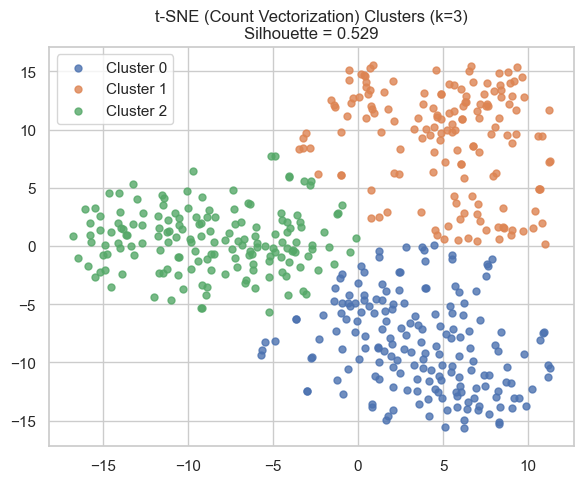

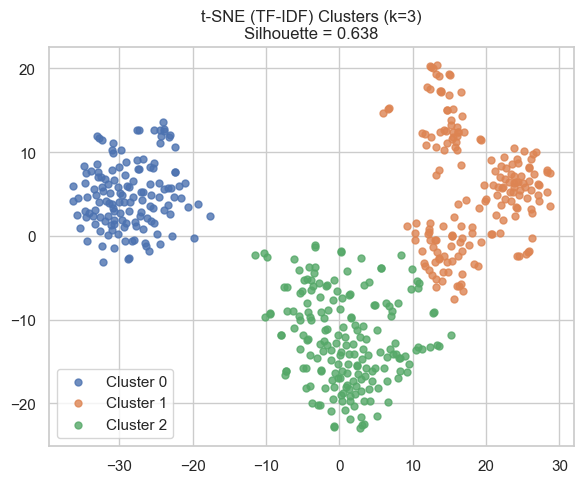

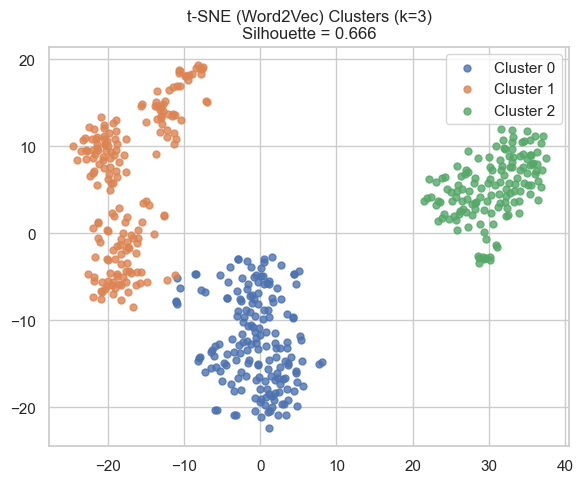

In [37]:
# ===========================
# (f) t-SNE Clustering & Visualization (Count, TF-IDF, Word2Vec)
# ===========================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

k = 3  # number of clusters
print(f"[INFO] Running KMeans clustering (k={k}) on t-SNE embeddings...")

# --- Cluster t-SNE embeddings ---
kmeans_tsne_count = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_tsne_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_tsne_w2v = KMeans(n_clusters=k, random_state=42, n_init=10)

labels_tsne_count = kmeans_tsne_count.fit_predict(coords_tsne_count)
labels_tsne_tfidf = kmeans_tsne_tfidf.fit_predict(coords_tsne_tfidf)
labels_tsne_w2v = kmeans_tsne_w2v.fit_predict(coords_tsne_w2v)

# --- Compute silhouette scores ---
sil_count_tsne = silhouette_score(coords_tsne_count, labels_tsne_count)
sil_tfidf_tsne = silhouette_score(coords_tsne_tfidf, labels_tsne_tfidf)
sil_w2v_tsne = silhouette_score(coords_tsne_w2v, labels_tsne_w2v)

print(f"Silhouette Score (t-SNE Count): {sil_count_tsne:.4f}")
print(f"Silhouette Score (t-SNE TF-IDF): {sil_tfidf_tsne:.4f}")
print(f"Silhouette Score (t-SNE Word2Vec): {sil_w2v_tsne:.4f}")

# --- Plot Count Vectorization clusters ---
plt.figure(figsize=(6,5))
for lbl in np.unique(labels_tsne_count):
    mask = labels_tsne_count == lbl
    plt.scatter(coords_tsne_count[mask,0], coords_tsne_count[mask,1],
                s=25, alpha=0.8, label=f"Cluster {lbl}")
plt.legend()
plt.title(f"t-SNE (Count Vectorization) Clusters (k={k})\nSilhouette = {sil_count_tsne:.3f}")
plt.tight_layout()
plt.show()

# --- Plot TF-IDF clusters ---
plt.figure(figsize=(6,5))
for lbl in np.unique(labels_tsne_tfidf):
    mask = labels_tsne_tfidf == lbl
    plt.scatter(coords_tsne_tfidf[mask,0], coords_tsne_tfidf[mask,1],
                s=25, alpha=0.8, label=f"Cluster {lbl}")
plt.legend()
plt.title(f"t-SNE (TF-IDF) Clusters (k={k})\nSilhouette = {sil_tfidf_tsne:.3f}")
plt.tight_layout()
plt.show()

# --- Plot Word2Vec clusters ---
plt.figure(figsize=(6,5))
for lbl in np.unique(labels_tsne_w2v):
    mask = labels_tsne_w2v == lbl
    plt.scatter(coords_tsne_w2v[mask,0], coords_tsne_w2v[mask,1],
                s=25, alpha=0.8, label=f"Cluster {lbl}")
plt.legend()
plt.title(f"t-SNE (Word2Vec) Clusters (k={k})\nSilhouette = {sil_w2v_tsne:.3f}")
plt.tight_layout()
plt.show()


In [ ]:
Prompt : Give me the code to perform k means clustering on vector representations

In [43]:
# ===========================
# (f, g) Clustering & Analysis (Count, TF-IDF, Word2Vec)
# ===========================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

k = 6  # chosen number of clusters

# --- KMeans clustering for all three representations ---
kmeans_count = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_count.toarray())
kmeans_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_tfidf.toarray())
kmeans_w2v = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_w2v)

# --- Cluster sizes ---
print("Count Vectorization Cluster sizes:", np.bincount(kmeans_count.labels_))
print("TF-IDF Cluster sizes:", np.bincount(kmeans_tfidf.labels_))
print("Word2Vec Cluster sizes:", np.bincount(kmeans_w2v.labels_))

# --- Silhouette Scores ---
sil_count = silhouette_score(X_count.toarray(), kmeans_count.labels_)
sil_tfidf = silhouette_score(X_tfidf.toarray(), kmeans_tfidf.labels_)
sil_w2v = silhouette_score(X_w2v, kmeans_w2v.labels_)

print("\nSilhouette Scores:")
print(f" Count Vectorization: {sil_count:.4f}")
print(f" TF-IDF: {sil_tfidf:.4f}")
print(f" Word2Vec: {sil_w2v:.4f}")

# --- Optional: Compare performance summary ---
print("\nSummary:")
best_method = max(
    [("Count Vectorization", sil_count), 
     ("TF-IDF", sil_tfidf), 
     ("Word2Vec", sil_w2v)],
    key=lambda x: x[1]
)
print(f" Best clustering performance achieved using: {best_method[0]} (Silhouette = {best_method[1]:.4f})")


Count Vectorization Cluster sizes: [  82  171  130  168  326 1671]
TF-IDF Cluster sizes: [ 203  165 1519  125  412  124]
Word2Vec Cluster sizes: [351 520 793 145 426 313]

Silhouette Scores:
 Count Vectorization: 0.1197
 TF-IDF: 0.0548
 Word2Vec: 0.1611

Summary:
 Best clustering performance achieved using: Word2Vec (Silhouette = 0.1611)


In [ ]:
Code for problem statement 1
Prompt : Give me the most matching documents for a given topic using cosine similarity

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# --- Choose embedding ---
embedding = "tfidf"  # options: "tfidf", "w2v"

if embedding == "tfidf":
    vectorizer = tfidf_vectorizer
    doc_vectors = X_tfidf.toarray()
elif embedding == "w2v":
    vectorizer = None
    doc_vectors = X_w2v

# --- Define query topic ---
query = "neural networks and deep learning"

# Convert query to vector
if embedding == "tfidf":
    query_vec = vectorizer.transform([query]).toarray()
else:  # Word2Vec
    words = query.split()
    query_vec = np.mean([w2v_model.wv[w] for w in words if w in w2v_model.wv], axis=0).reshape(1, -1)

# --- Compute cosine similarity ---
sims = cosine_similarity(query_vec, doc_vectors).flatten()
top_idx = sims.argsort()[::-1][:5]

print("\n🔎 Top 5 matching submissions for query:", query)
for rank, i in enumerate(top_idx, start=1):
    print(f"{rank}. (Score={sims[i]:.3f}) -> {df['preprocessed_text'].iloc[i][:150]}...")



🔎 Top 5 matching submissions for query: neural networks and deep learning
1. (Score=0.278) -> convulutional neural network today class learnt convolutional neural network cnns play major role field deep learning especially image recognition com...
2. (Score=0.247) -> neural network manage overfit topic chosen neural network manage overfit quite intuitive parameter lead overfitting polynomial regression x n perfectl...
3. (Score=0.226) -> feature extraction involved image analysis approach purposefully avoids using automatic embedding model like convolutional neural network instead focu...
4. (Score=0.221) -> convolutional neural network convolutional neural network cnn specialised deep learning model designed process grid like data image exploiting spatial...
5. (Score=0.221) -> sigmoid function alternative sigmoid function mathematical function defined sigma x exp x shaped curve smoothly map real number value make especially ...


In [ ]:
Code for problem statement 2
Prompt : Give me a code to find the outlier of each cluster by finding the document with the largest euclidean distance from the centroid of the cluster

In [45]:
# ===========================
# (g) Find least fitting (outlier) document per cluster
# ===========================
from scipy.spatial.distance import cdist

def find_outliers(coords, labels, df, method_name):
    """Find the document farthest from centroid in each cluster."""
    outliers = []
    for cluster_id in np.unique(labels):
        cluster_points = coords[labels == cluster_id]
        centroid = np.mean(cluster_points, axis=0)
        distances = cdist(cluster_points, [centroid], metric='euclidean').flatten()
        outlier_idx = np.argmax(distances)
        global_idx = np.where(labels == cluster_id)[0][outlier_idx]
        outliers.append((cluster_id, global_idx, distances[outlier_idx]))
    
    print(f"\nOutlier documents for {method_name}:")
    for cid, idx, dist in outliers:
        print(f" - Cluster {cid}: Document {idx} (Distance = {dist:.3f})")
        print(f"   Text: {df['preprocessed_text'].iloc[idx][:200]}...\n")
    return outliers

# Run for all three embeddings
outliers_count = find_outliers(coords_tsne_count, labels_tsne_count, df, "Count Vectorization (t-SNE)")
outliers_tfidf = find_outliers(coords_tsne_tfidf, labels_tsne_tfidf, df, "TF-IDF (t-SNE)")
outliers_w2v = find_outliers(coords_tsne_w2v, labels_tsne_w2v, df, "Word2Vec (t-SNE)")



Outlier documents for Count Vectorization (t-SNE):
 - Cluster 0: Document 335 (Distance = 9.350)
   Text: vanishing sigma yi yi hat yi hat bar term derivation r computation variance expressed yi bar yi yi hat yi hat bar squared give u sigma yi yi hat yi hat bar one term vanishes give u final formula let u...

 - Cluster 1: Document 370 (Distance = 10.689)
   Text: measure regression model actually good confident conclusion much story model tell r squared professor introduced something called coefficient determination r squared r score tell u much variation outp...

 - Cluster 2: Document 367 (Distance = 8.445)
   Text: r important calculate suppose thousand datapoints data set used either slr odr plot line dataset ready use prediction first check assess accurate model e much varying original label value axis purpose...


Outlier documents for TF-IDF (t-SNE):
 - Cluster 0: Document 306 (Distance = 11.349)
   Text: lecture intro intro data science connects many topic machine learning ma

In [47]:
Code for problem statement 3
Prompt : Give me the code to find submissions whose distances are greater than critical value

SyntaxError: invalid syntax (1005997696.py, line 1)

In [46]:
# ===========================
# (h) Identify highly similar (possibly copied) document pairs
# ===========================
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

# --- Choose representation: you can repeat for TF-IDF, Word2Vec, etc. ---
X_used = X_tfidf.toarray()
method_name = "TF-IDF"

# Compute pairwise distances/similarities
euclid_dist = euclidean_distances(X_used)
cos_sim = cosine_similarity(X_used)

# Define thresholds for "high similarity" (tunable)
cosine_threshold = 0.95   # High cosine similarity → nearly identical
euclid_threshold = 0.3    # Small Euclidean distance → nearly identical

similar_pairs = []
n_docs = euclid_dist.shape[0]

for i in range(n_docs):
    for j in range(i + 1, n_docs):
        if cos_sim[i, j] > cosine_threshold and euclid_dist[i, j] < euclid_threshold:
            similar_pairs.append((i, j, cos_sim[i, j], euclid_dist[i, j]))

print(f"\nHighly similar document pairs ({method_name}):")
if similar_pairs:
    for (i, j, cosv, eucv) in similar_pairs:
        print(f" - Docs {i} & {j}: Cosine = {cosv:.3f}, Euclid = {eucv:.3f}")
        print(f"   Doc {i}: {df['preprocessed_text'].iloc[i][:120]}...")
        print(f"   Doc {j}: {df['preprocessed_text'].iloc[j][:120]}...\n")
else:
    print("No pairs found above the threshold.")



Highly similar document pairs (TF-IDF):
 - Docs 216 & 217: Cosine = 1.000, Euclid = 0.000
   Doc 216: simple linear regression slr today class learnt simple linear regression done using excel using dataset sale v advertise...
   Doc 217: simple linear regression slr today class learnt simple linear regression done using excel using dataset sale v advertise...

 - Docs 274 & 279: Cosine = 0.999, Euclid = 0.037
   Doc 274: simple linear regression started class looking sale advertisement example scattered plot given looked different line pre...
   Doc 279: linear regression started class looking sale advertisement example scattered plot given looked different line prediction...

 - Docs 791 & 792: Cosine = 1.000, Euclid = 0.000
   Doc 791: regression hypothesis testing anova model selection regression basic model objective minimize squared error ols ordinary...
   Doc 792: regression hypothesis testing anova model selection regression basic model objective minimize squared error ols ord